## Import Libraries

In [174]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px


In [175]:
df=pd.read_csv("Hospital_ER_Data.csv")                     # import data

In [176]:
df.head()                                       

,Patient Id,Patient Admission Date,Patient First Inital,Patient Last Name,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime,Patients CM
0,145-39-5406,20-03-2024 08:47,H,Glasspool,M,69,White,NaN,False,10.0,39,0
1,316-34-3057,15-06-2024 11:29,X,Methuen,M,4,Native American/Alaska Native,NaN,True,NaN,27,0
2,897-46-3852,20-06-2024 09:13,P,Schubuser,F,56,African American,General Practice,True,9.0,55,0
3,358-31-9711,04-02-2024 22:34,U,Titcombe,F,24,Native American/Alaska Native,General Practice,True,8.0,31,0
4,289-26-0537,04-09-2024 17:48,Y,Gionettitti,M,5,African American,Orthopedics,False,NaN,10,0


In [177]:
df.shape

(9216, 12)

In [178]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient Id                  9216 non-null   object 
 1   Patient Admission Date      9216 non-null   object 
 2   Patient First Inital        9216 non-null   object 
 3   Patient Last Name           9216 non-null   object 
 4   Patient Gender              9216 non-null   object 
 5   Patient Age                 9216 non-null   int64  
 6   Patient Race                9216 non-null   object 
 7   Department Referral         3816 non-null   object 
 8   Patient Admission Flag      9216 non-null   bool   
 9   Patient Satisfaction Score  2517 non-null   float64
 10  Patient Waittime            9216 non-null   int64  
 11  Patients CM                 9216 non-null   int64  
dtypes: bool(1), float64(1), int64(3), object(7)
memory usage: 801.1+ KB


In [179]:
df.describe()

,Patient Age,Patient Satisfaction Score,Patient Waittime,Patients CM
count,9216.000000,2517.000000,9216.000000,9216.000000
mean,39.855143,4.992054,35.259874,0.052083
std,22.755125,3.138043,14.735323,0.222207
min,1.000000,0.000000,10.000000,0.000000
25%,20.000000,2.000000,23.000000,0.000000
50%,39.000000,5.000000,35.000000,0.000000
75%,60.000000,8.000000,48.000000,0.000000
max,79.000000,10.000000,60.000000,1.000000


In [180]:
df.columns

Index(['Patient Id', 'Patient Admission Date', 'Patient First Inital',
       'Patient Last Name', 'Patient Gender', 'Patient Age', 'Patient Race',
       'Department Referral', 'Patient Admission Flag',
       'Patient Satisfaction Score', 'Patient Waittime', 'Patients CM'],
      dtype='object')

## Data Cleaning

In [181]:
df.drop_duplicates(inplace=True)

In [182]:
df.isnull().sum()

Patient Id                       0
Patient Admission Date           0
Patient First Inital             0
Patient Last Name                0
Patient Gender                   0
Patient Age                      0
Patient Race                     0
Department Referral           5400
Patient Admission Flag           0
Patient Satisfaction Score    6699
Patient Waittime                 0
Patients CM                      0
dtype: int64

In [183]:
df["Department Referral"]=df["Department Referral"].fillna("Direct Admit")

In [184]:
df["Patient Satisfaction Score"]=(df.groupby("Department Referral")["Patient Satisfaction Score"]
    .transform(lambda x:x.fillna(x.median())))

In [185]:
df["Patient Admission Date"] = pd.to_datetime(
    df["Patient Admission Date"],
    dayfirst=True
)

## Feature Engineering

In [186]:
df["Month"]=df["Patient Admission Date"].dt.month_name()                # Create Month Column

In [187]:
df["Year"]=df["Patient Admission Date"].dt.year                        # Create Year Column

In [188]:
df["Day"]=df["Patient Admission Date"].dt.day_name()                   # Create weekday column

In [189]:
df["Full Name"]=df["Patient First Inital"] +" "+df["Patient Last Name"]   # Create full name column

In [190]:
df["Patient Gender"].unique()

array(['M', 'F', 'NC'], dtype=object)

In [191]:
# Replace in  Patient Gender 

df["Patient Gender"]=df["Patient Gender"].replace({
    "M":"Male",
    "F":"Female",
    "NC":"Not Confirmed"
})

In [192]:
df["Hour"] = df["Patient Admission Date"].dt.hour

In [193]:
df.isnull().sum()                    # cheak exist null values or no

Patient Id                    0
Patient Admission Date        0
Patient First Inital          0
Patient Last Name             0
Patient Gender                0
Patient Age                   0
Patient Race                  0
Department Referral           0
Patient Admission Flag        0
Patient Satisfaction Score    0
Patient Waittime              0
Patients CM                   0
Month                         0
Year                          0
Day                           0
Full Name                     0
Hour                          0
dtype: int64

In [194]:
# Age Group

bins=[0,10,20,30,40,50,60,70,80,90,100]

labels=[
    "0-10","11-20","21-30","31-40","41-50","51-60","61-70","71-80","81-90","91-100"
]

df["Age Group"]=pd.cut(df["Patient Age"],
                      bins=bins,
                      labels=labels)

In [195]:
# Wait Time Category

df["Seen within 30 min"]=np.where(
    df["Patient Waittime"]<=30,
    "Yes",
    "No"
)

## Exploratory Data Analysis

In [196]:
# Monthly Patient

df.groupby("Month")["Patient Id"].count()

Month
April         948
August       1024
December      489
February      431
January       513
July          952
June          991
March         506
May           999
November      464
October       964
September     935
Name: Patient Id, dtype: int64

In [197]:
# Admission Status

df["Patient Admission Flag"].value_counts()

Patient Admission Flag
True     4612
False    4604
Name: count, dtype: int64

In [198]:
# Gender Distribution

df["Patient Gender"].value_counts()

Patient Gender
Male             4705
Female           4487
Not Confirmed      24
Name: count, dtype: int64

In [199]:
# Race Distribution

df["Patient Race"].value_counts()

Patient Race
White                            2571
African American                 1951
Two or More Races                1557
Asian                            1060
Declined to Identify             1030
Pacific Islander                  549
Native American/Alaska Native     498
Name: count, dtype: int64

In [200]:
# Departmet Referrals

df["Department Referral"].value_counts()

Department Referral
Direct Admit        5400
General Practice    1840
Orthopedics          995
Physiotherapy        276
Cardiology           248
Neurology            193
Gastroenterology     178
Renal                 86
Name: count, dtype: int64

In [201]:
# Average Wait Time

df["Patient Waittime"].mean()

np.float64(35.25987413194444)

In [202]:
# Age Distribution
df["Patient Age"].value_counts()

Patient Age
39    145
49    142
27    142
56    139
18    139
     ... 
20    101
1     101
44    100
21    100
75    100
Name: count, Length: 79, dtype: int64

In [203]:
# WeeKday Analysis

df.groupby("Day")["Patient Id"].count()

Day
Friday       1310
Monday       1314
Saturday     1377
Sunday       1318
Thursday     1332
Tuesday      1305
Wednesday    1260
Name: Patient Id, dtype: int64

In [204]:
# Hourly Patient Volume

df.groupby("Hour")["Patient Id"].count()

Hour
0     406
1     372
2     376
3     385
4     384
5     393
6     375
7     415
8     386
9     388
10    349
11    403
12    366
13    410
14    368
15    394
16    378
17    359
18    370
19    383
20    372
21    376
22    372
23    436
Name: Patient Id, dtype: int64

In [205]:
df.isnull().sum()

Patient Id                    0
Patient Admission Date        0
Patient First Inital          0
Patient Last Name             0
Patient Gender                0
Patient Age                   0
Patient Race                  0
Department Referral           0
Patient Admission Flag        0
Patient Satisfaction Score    0
Patient Waittime              0
Patients CM                   0
Month                         0
Year                          0
Day                           0
Full Name                     0
Hour                          0
Age Group                     0
Seen within 30 min            0
dtype: int64

In [206]:
# Seen Within 30 Minutes

df["Seen within 30 min"].value_counts(normalize=True)*100

Seen within 30 min
No     59.320747
Yes    40.679253
Name: proportion, dtype: float64

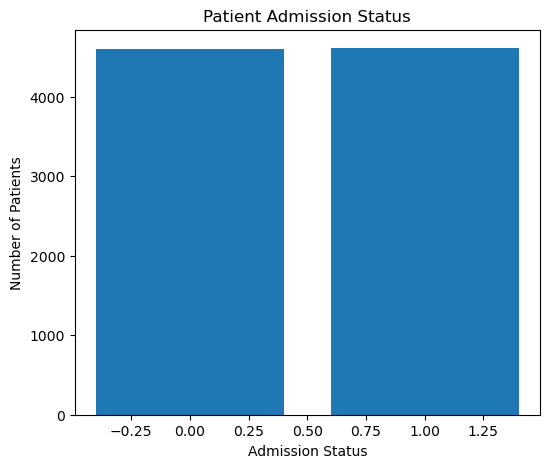

In [207]:
# Patient Admission Status

admission = df["Patient Admission Flag"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(admission.index, admission.values)
plt.title("Patient Admission Status")
plt.xlabel("Admission Status")
plt.ylabel("Number of Patients")
plt.show()

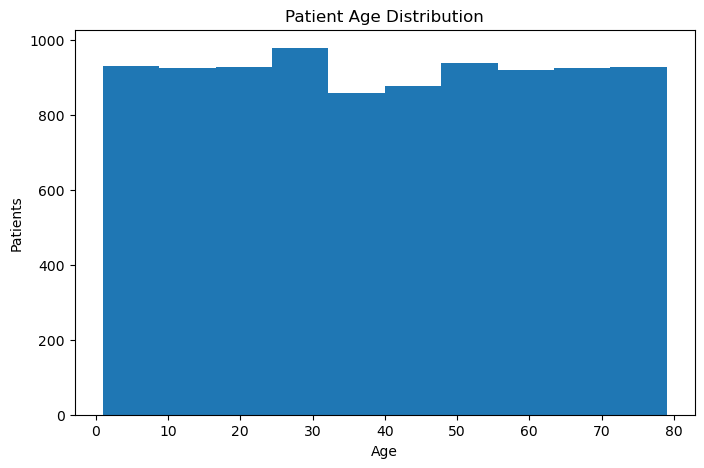

In [208]:
# Patient Age Distribution

plt.figure(figsize=(8,5))
plt.hist(df["Patient Age"], bins=10)
plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Patients")
plt.show()

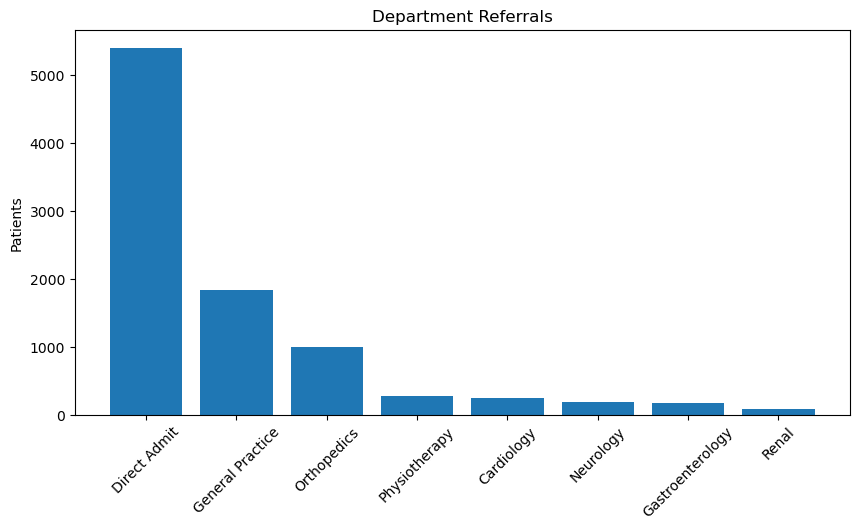

In [209]:
# Department Referrals

dept = df["Department Referral"].value_counts()

plt.figure(figsize=(10,5))
plt.bar(dept.index, dept.values)
plt.title("Department Referrals")
plt.xticks(rotation=45)
plt.ylabel("Patients")
plt.show()

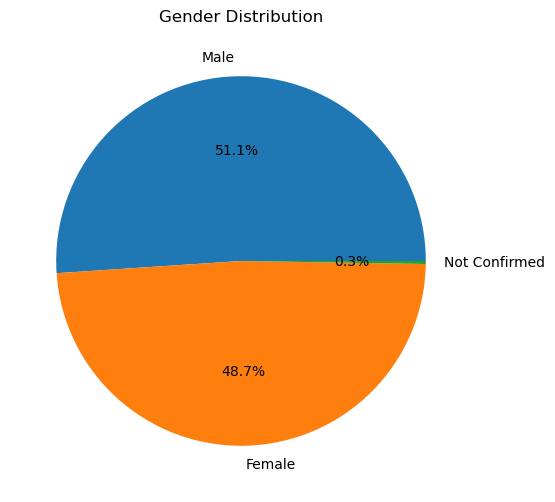

In [210]:
#Gender Distribution

gender = df["Patient Gender"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender.values,
        labels=gender.index,
        autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.show()

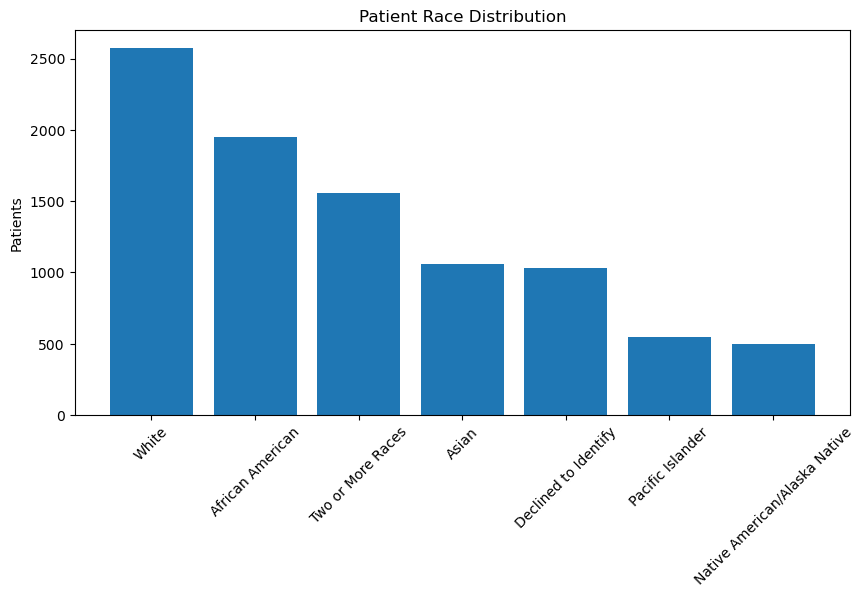

In [211]:
# Race Distribution

race = df["Patient Race"].value_counts()

plt.figure(figsize=(10,5))
plt.bar(race.index, race.values)
plt.xticks(rotation=45)
plt.title("Patient Race Distribution")
plt.ylabel("Patients")
plt.show()

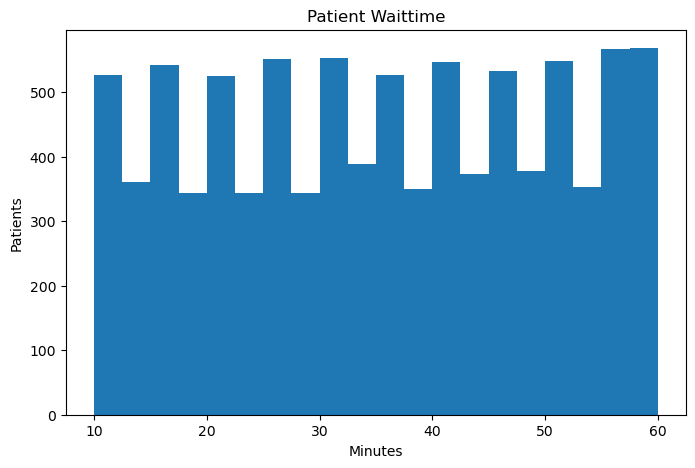

In [212]:
# Wait Time Distribution

plt.figure(figsize=(8,5))
plt.hist(df["Patient Waittime"], bins=20)
plt.title("Patient Waittime")
plt.xlabel("Minutes")
plt.ylabel("Patients")
plt.show()

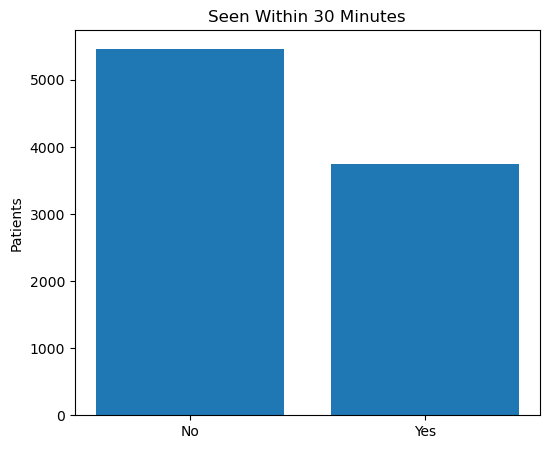

In [213]:
# Seen Within 30 Minutes

within30 = df["Seen within 30 min"].value_counts()

plt.figure(figsize=(6,5))
plt.bar(within30.index, within30.values)
plt.title("Seen Within 30 Minutes")
plt.ylabel("Patients")
plt.show()

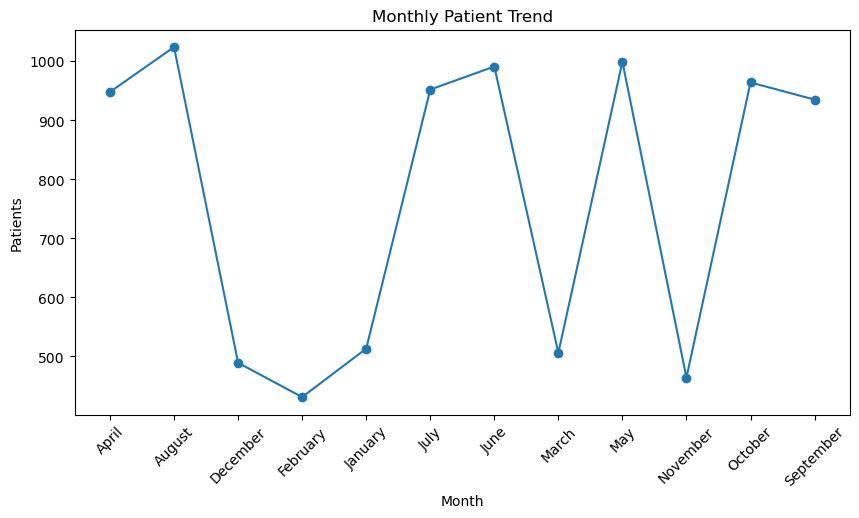

In [214]:
# Monthly Patient Trend

monthly = df.groupby("Month")["Patient Id"].count()

plt.figure(figsize=(10,5))
plt.plot(monthly.index, monthly.values, marker="o")
plt.title("Monthly Patient Trend")
plt.xlabel("Month")
plt.ylabel("Patients")
plt.xticks(rotation=45)
plt.show()

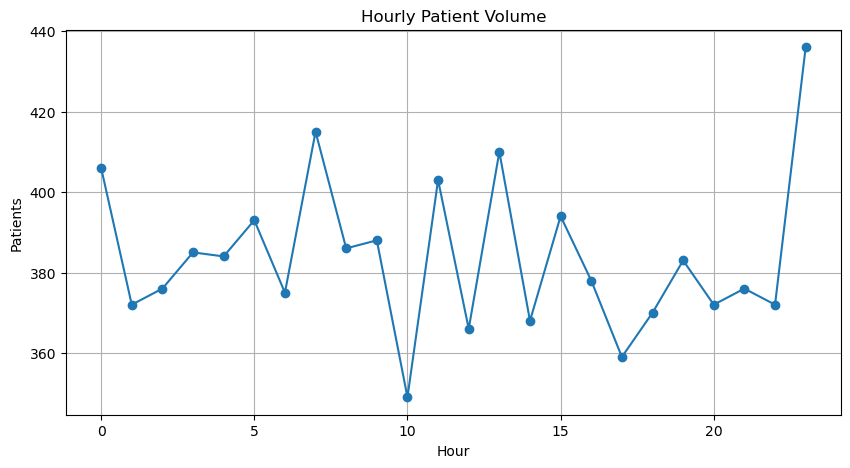

In [215]:
# Hourly Patient Volume

hourly = df.groupby("Hour")["Patient Id"].count()

plt.figure(figsize=(10,5))
plt.plot(hourly.index, hourly.values, marker="o")
plt.title("Hourly Patient Volume")
plt.xlabel("Hour")
plt.ylabel("Patients")
plt.grid(True)
plt.show()

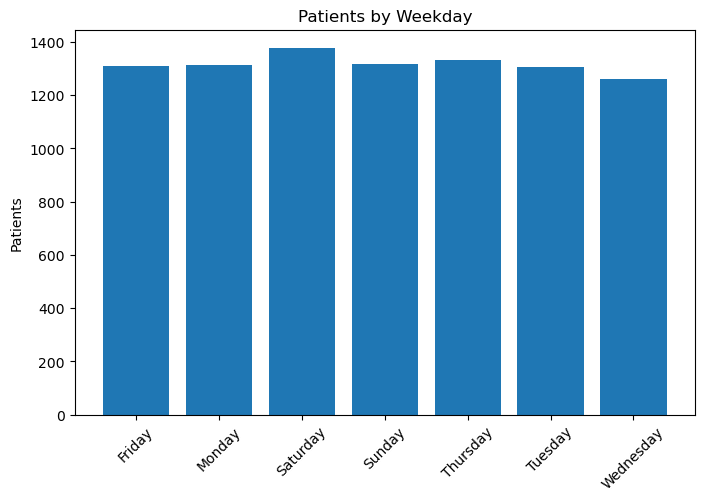

In [216]:
# Daily Patient Volume

daily = df.groupby("Day")["Patient Id"].count()

plt.figure(figsize=(8,5))
plt.bar(daily.index, daily.values)
plt.title("Patients by Weekday")
plt.ylabel("Patients")
plt.xticks(rotation=45)
plt.show()

## Export Clean Dataset

In [218]:
# Export Clean Dataset

df.to_csv("Hospital_Cleaned.csv",index=False)